In [1]:
import os
import numpy as np
import skimage
from skimage.feature import local_binary_pattern
import time


# Ellipitical Flow 
# laminar_folder = 'cfd_flow_image_analysis\data\elliptic\Laminar'
# turbulent_folder = 'cfd_flow_image_analysis\data\elliptic\Turbulent'

# Aerofoil Flow 
laminar_folder = 'cfd_flow_image_analysis\data\aerofoil\Laminar_aero'
turbulent_folder = 'cfd_flow_image_analysis\data\aerofoil\Turbulent_aero'

# Load the images and extract LBP features
X_laminar = [os.path.join(laminar_folder, f) for f in os.listdir(laminar_folder)]
X_turbulent = [os.path.join(turbulent_folder, f) for f in os.listdir(turbulent_folder)]

X = []
y = []
labels = ['Laminar', 'Turbulent']
start_time = time.time()
for img_path in X_laminar:
    img = skimage.io.imread(img_path, as_gray=True)
    img_uint8 = skimage.img_as_ubyte(img)

    lbp = local_binary_pattern(img_uint8, 8, 1, 'default')
    hist, _ = np.histogram(lbp, bins=np.arange(0, 256+1), density=True)
    X.append(hist)
    y.append(0)  # 0 for laminar
end_time = time.time()
lamtime=(end_time - start_time)
print("The lam feature time:" + str(lamtime))

start_time = time.time()
for img_path in X_turbulent:
    img = skimage.io.imread(img_path, as_gray=True)
    img_uint8 = skimage.img_as_ubyte(img)
    lbp = local_binary_pattern(img_uint8, 8, 1, 'default')
    hist, _ = np.histogram(lbp, bins=np.arange(0, 256+1), density=True)
    X.append(hist)
    y.append(1)  # 1 for turbulent
end_time = time.time()
turtime=(end_time - start_time)
print("The turb feature time:" + str(turtime))

X = np.array(X)
y = np.array(y)
total_time = lamtime+turtime
num_images = len(X_laminar) + len(X_turbulent)
print(f"Average LBP computation time per image: {total_time / num_images:.6f} seconds")

The lam feature time:65.2290563583374
The turb feature time:64.41490840911865
Average LBP computation time per image: 0.259288 seconds


In [2]:
print("The lam feature time:" + str(lamtime))

The lam feature time:65.2290563583374


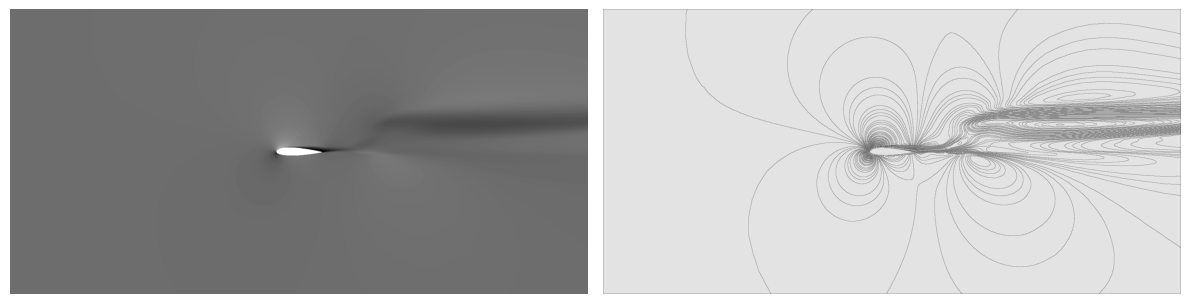

<Figure size 640x480 with 0 Axes>

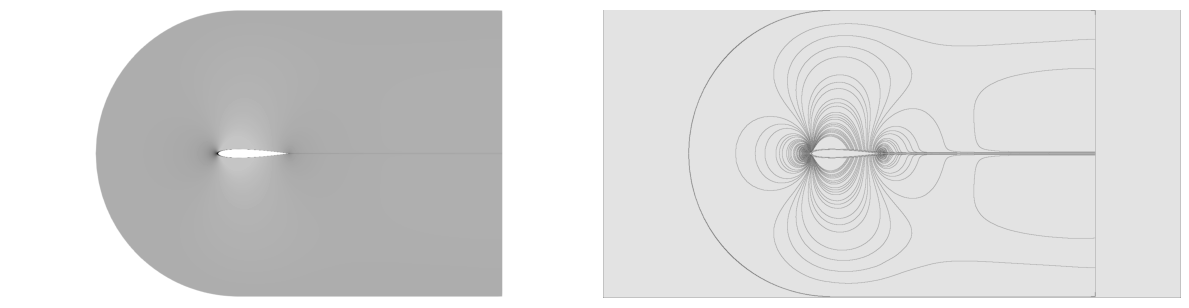

<Figure size 640x480 with 0 Axes>

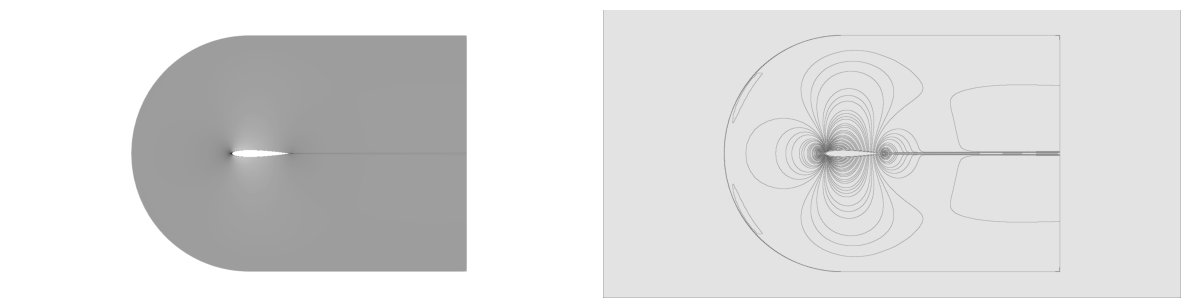

<Figure size 640x480 with 0 Axes>

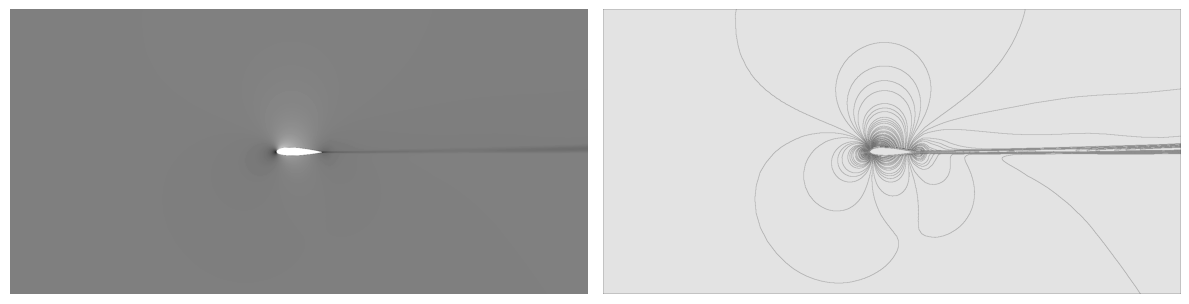

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt

def plot_lbp(img_path, title):
    img = skimage.io.imread(img_path, as_gray=True)
    img_uint8 = skimage.img_as_ubyte(img)
    lbp = local_binary_pattern(img_uint8, 8,1, 'uniform')
    
    plt.figure(figsize=(12, 6))
    plt.subplot(121)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    plt.subplot(122)
    plt.imshow(lbp, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot 2 laminar images
for i, img_path in enumerate(X_laminar[1:3]):
    plot_lbp(img_path, f'Laminar {i+1}')
    plt.savefig(f'lbp_{i}_Laminar_{i+1}.png')

# Plot 2 turbulent images
for i, img_path in enumerate(X_turbulent[14:16]):
    plot_lbp(img_path, f'Turbulent {i+1}')
    plt.savefig(f'lbp_{i}_Turbulent_{i+1}.png')

[(24, 243), (16, 60), (14, 240), (29, 247)]


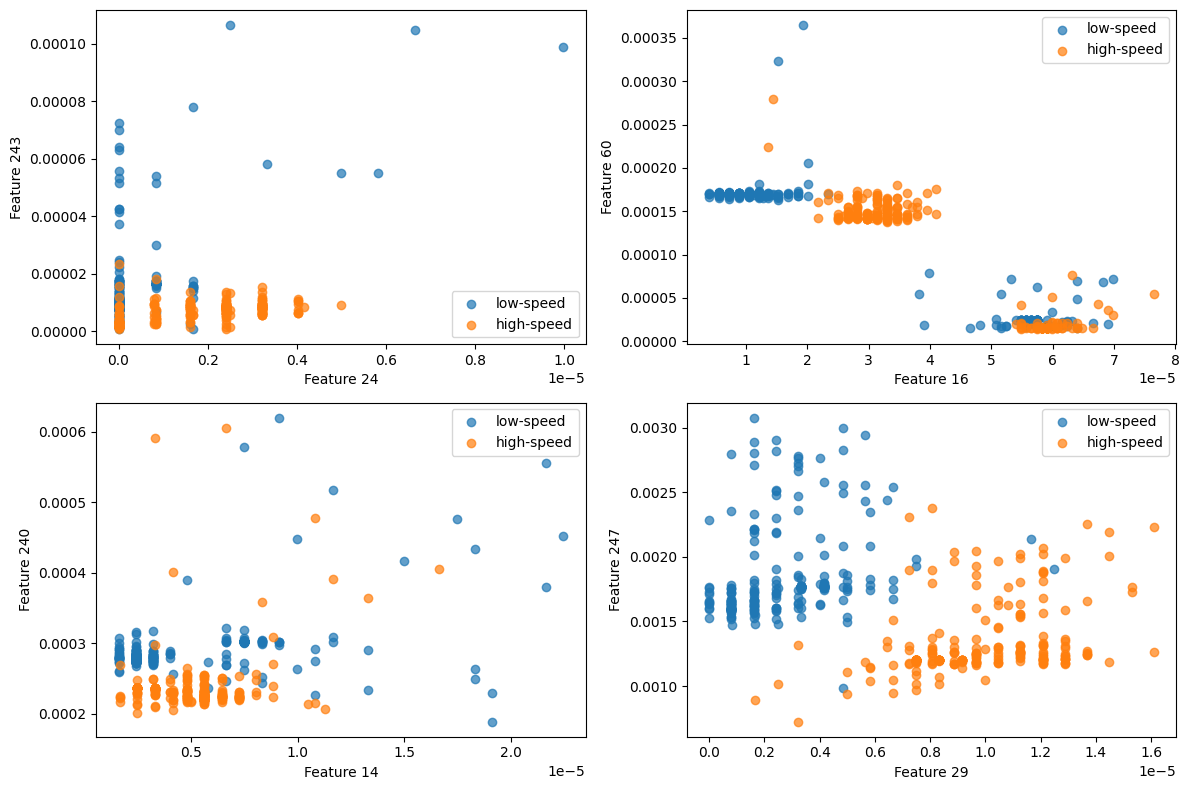

In [4]:
import random

# Assuming you have unique class labels in the 'y' variable
unique_labels = np.unique(y)
label_names = ['low-speed', 'high-speed']  # Assign the desired label names

# Get the number of features
num_features = X.shape[1]

# Randomly select four pairs of two features
feature_pairs=[(24,243), (16,60), (14,240), (29, 247)]
# feature_pairs = random.sample([(i, j) for i in range(num_features) for j in range(i + 1, num_features)], 4)
print(feature_pairs)
# Create a scatter plot for each feature pair
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

# Issue 1: Indentation is incorrect for the loop
for i, (feat1, feat2) in enumerate(feature_pairs):  # Corrected indentation
    for j, label in enumerate(unique_labels):
        class_idx = (y == label)
        axs[i].scatter(X[class_idx, feat1], X[class_idx, feat2], label=label_names[j], alpha=0.7)  # Corrected 'ax' to 'axs[i]'
        axs[i].set_xlabel(f'Feature {feat1}')
        axs[i].set_ylabel(f'Feature {feat2}')
        axs[i].legend(loc='best')
        # axs[i].set_title(f'Scatter Plot {i + 1}')

plt.tight_layout()
plt.savefig('FeaturePlot_LBP.png', dpi=300)
plt.show()




In [5]:
from sklearn.model_selection import cross_val_predict, GridSearchCV 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Define classifiers with their parameter grids
classifiers = [
    ('k-NN', KNeighborsClassifier(), {'n_neighbors': [3, 5, 7, 9, 11]}),
    ('SVM (linear)', SVC(kernel='linear', probability=True), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.1, 1]}),
    ('Random Forest', RandomForestClassifier(), {'n_estimators': [1], 'max_depth': [None, 1]})
]

# Define line styles for the plot
line_styles = ['-', '--', '-.']

# Initialize ROC curve plot
plt.figure(figsize=(8, 6))

for idx, (name, clf, param_grid) in enumerate(classifiers):
    print(f'Evaluating {name} classifier:')
    
    # Perform GridSearchCV for hyperparameter tuning with 10-fold cross-validation
    grid_search = GridSearchCV(clf, param_grid, cv=10, scoring='accuracy')
    grid_search.fit(X, y)
    
    # Use the best estimator for predictions
    best_clf = grid_search.best_estimator_
    
    # Predict the probabilities or decision function using cross-validation
    if hasattr(best_clf, "predict_proba"):
        y_prob = cross_val_predict(best_clf, X, y, cv=10, method="predict_proba")[:, 1]
    else:
        y_prob = cross_val_predict(best_clf, X, y, cv=10, method="decision_function")
    
    # Confusion Matrix
    y_pred = cross_val_predict(best_clf, X, y, cv=10)
    cm = confusion_matrix(y, y_pred)
    
    # Calculate Metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc_value = auc(fpr, tpr)
    
    # Print the metrics
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"AUC: {auc_value:.4f}")
    
    # Create confusion matrix plot with thicker lines and larger font size
    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Laminar', 'Turbulent'])
    disp.plot(ax=ax, cmap='viridis', values_format='d')  # Use 'd' for displaying integer counts
    
    # Modify line thickness
    for spine in ax.spines.values():
        spine.set_linewidth(14)  # Set line thickness
    
    # Modify font size of text in confusion matrix
    for labels in ax.texts:
        labels.set_fontsize(16)  # Set font size of the numbers inside the matrix
    
    # Save the figure to a JPG file in 300 DPI without a title
    plt.savefig(f'{name}_Confusion_Matrix.jpg', dpi=300, bbox_inches='tight', format='jpg')

    # Close the figure after saving to avoid display
    plt.close()
    
    print(f'Best parameters for {name}: {grid_search.best_params_}')
    print(f'Best cross-validation score for {name}: {grid_search.best_score_:.4f}')
    print('\n' + '='*50 + '\n')


Evaluating k-NN classifier:
Accuracy: 0.9720
Precision: 0.9797
Recall (Sensitivity): 0.9640
F1 Score: 0.9718
Specificity: 0.9800
AUC: 0.9848
Best parameters for k-NN: {'n_neighbors': 3}
Best cross-validation score for k-NN: 0.9720


Evaluating SVM (linear) classifier:
Accuracy: 0.6360
Precision: 0.5895
Recall (Sensitivity): 0.8960
F1 Score: 0.7111
Specificity: 0.3760
AUC: 0.8810
Best parameters for SVM (linear): {'C': 100, 'gamma': 'scale'}
Best cross-validation score for SVM (linear): 0.6360


Evaluating Random Forest classifier:
Accuracy: 0.9780
Precision: 0.9723
Recall (Sensitivity): 0.9840
F1 Score: 0.9781
Specificity: 0.9720
AUC: 0.9780
Best parameters for Random Forest: {'max_depth': None, 'n_estimators': 1}
Best cross-validation score for Random Forest: 0.9740




<Figure size 800x600 with 0 Axes>